## Best Lambda Value

In [1]:
from Pipeline.Algorithm.ArtificialBeeColonyElm import ArtificialBeeColonyElm
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Global.Plotting import Plotting
from Pipeline.Methodology.ABC_Testing import abc_testing

In [2]:
gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_data_path_1()

features_size = gallstone_dataset.x_train.shape[1]
x_train_scaled = gallstone_dataset.x_train_scaled
x_test_scaled  = gallstone_dataset.x_test_scaled
y_train = gallstone_dataset.y_train
y_test  = gallstone_dataset.y_test

In [3]:
mod = "Best_Lambda"

In [4]:
best_lambda_config = GlobalSetting.get_config_by_type(mod)
best_lamda_hidden_size = best_lambda_config["Hidden_Nodes"] if best_lambda_config else None
best_lamda_lambda_value = best_lambda_config["Lambda_Value"] if best_lambda_config else None

In [5]:
abc_elm_hidden  = ArtificialBeeColonyElm(
    features_size       = features_size,
    hidden_size         = best_lamda_hidden_size,
    activation_function = GlobalSetting.sigmoid             ,
    regularization_lambda=best_lamda_lambda_value           ,
    fitness_function    = GlobalSetting.evaluation_function ,
    solution_size       = GlobalSetting.solution_size       ,
    trial_limit         = GlobalSetting.trial_limit         ,
    max_iteration       = GlobalSetting.max_iteration
)

In [6]:
results_df , convergence_df , scout_df = abc_testing(abc_elm_hidden, x_train_scaled, y_train, x_test_scaled, y_test)
results_df.describe()

Seed 41 start

Iteration 1 end : 0.0307s | Scout Triggers: 0
Iteration 2 end : 0.0322s | Scout Triggers: 0
Iteration 3 end : 0.0329s | Scout Triggers: 0
Iteration 4 end : 0.0399s | Scout Triggers: 0
Iteration 5 end : 0.0355s | Scout Triggers: 0
Iteration 6 end : 0.0363s | Scout Triggers: 0
Iteration 7 end : 0.0345s | Scout Triggers: 0
Iteration 8 end : 0.0308s | Scout Triggers: 0
Iteration 9 end : 0.0328s | Scout Triggers: 1
Iteration 10 end : 0.0347s | Scout Triggers: 0
Iteration 11 end : 0.0357s | Scout Triggers: 0
Iteration 12 end : 0.0349s | Scout Triggers: 0
Iteration 13 end : 0.0318s | Scout Triggers: 0
Iteration 14 end : 0.0363s | Scout Triggers: 0
Iteration 15 end : 0.0349s | Scout Triggers: 0
Iteration 16 end : 0.0324s | Scout Triggers: 1
Iteration 17 end : 0.0331s | Scout Triggers: 1
Iteration 18 end : 0.0379s | Scout Triggers: 2
Iteration 19 end : 0.0349s | Scout Triggers: 0
Iteration 20 end : 0.0346s | Scout Triggers: 0
Iteration 21 end : 0.0325s | Scout Triggers: 0
Iterati

,Accuracy,Precision,Recall,NPV,Specificity,F1-Score,F2-Score,Bal Accuracy,MCC,ABC_Seed
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.779167,0.781848,0.776042,0.780144,0.782292,0.777517,0.776325,0.779167,0.560150,55.500000
std,0.035709,0.034464,0.064140,0.048663,0.043023,0.040249,0.053987,0.035709,0.071033,8.803408
min,0.703125,0.709677,0.625000,0.696970,0.718750,0.698413,0.657895,0.703125,0.406449,41.000000
25%,0.750000,0.759358,0.726562,0.742166,0.750000,0.747847,0.735698,0.750000,0.507064,48.250000
50%,0.781250,0.786797,0.781250,0.777722,0.781250,0.777722,0.778824,0.781250,0.562500,55.500000
75%,0.796875,0.806452,0.812500,0.804839,0.812500,0.798413,0.806207,0.796875,0.594040,62.750000
max,0.875000,0.852941,0.906250,0.900000,0.875000,0.878788,0.895062,0.875000,0.751469,70.000000


[I/O Trace] Figure exported successfully: ../../Storage/Figure\ABC_Telemetry_Best_Lambda_F1-Score.png


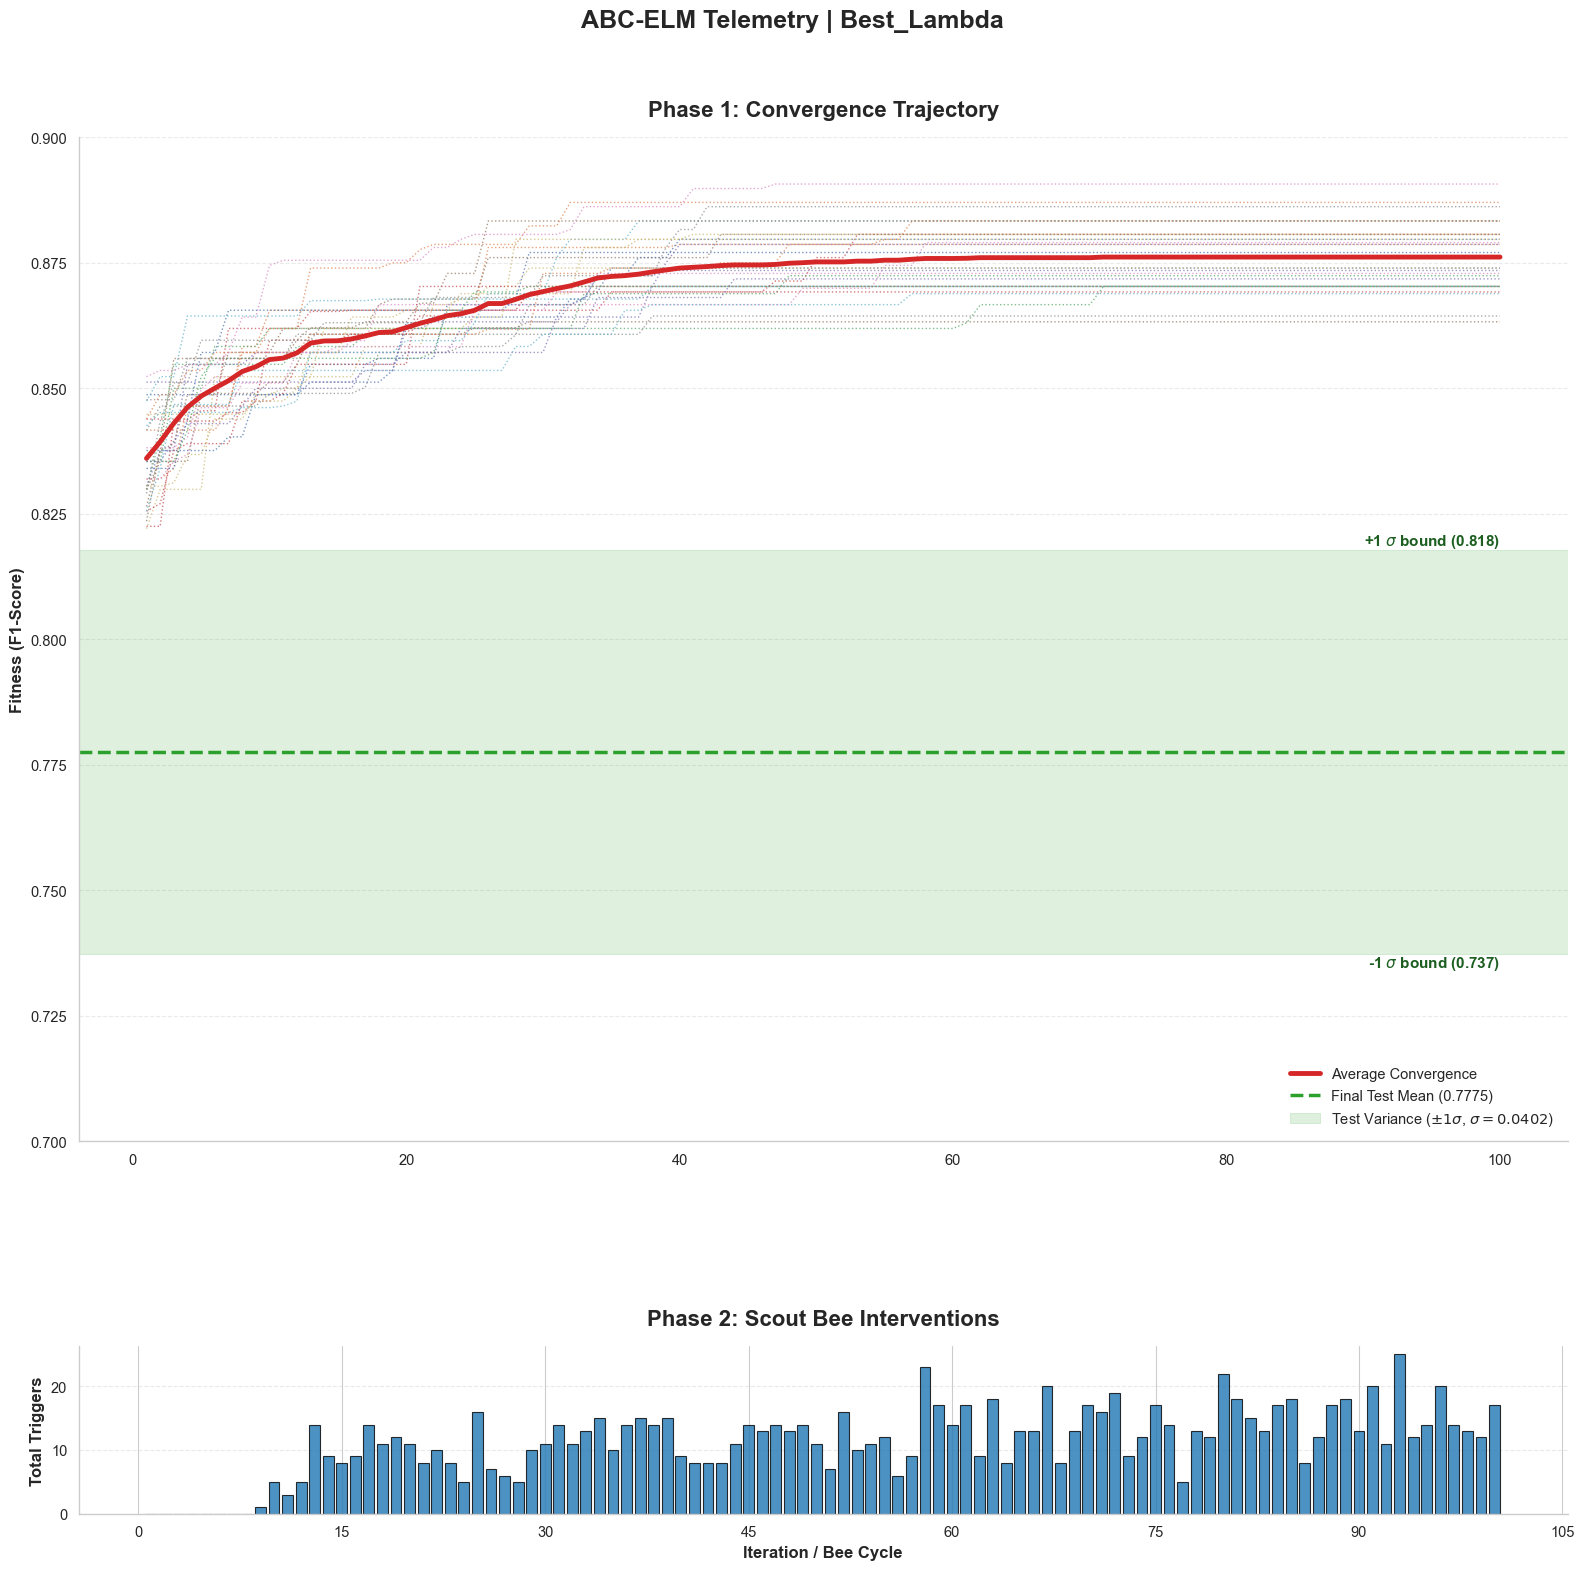

In [7]:
Plotting.plot_abc_dashboard(
    convergence_df,
    scout_df,
    mod,
    results_df,
    is_final_record=True)

In [8]:
GlobalSetting.save_dataframe_to_record(results_df, f"ABC_{mod}_Results.csv")

GlobalSetting.save_dataframe_to_record(convergence_df, f'ABC_{mod}_Convergence.csv')

GlobalSetting.save_dataframe_to_record(scout_df, f'ABC_{mod}_Scout_History.csv')

[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Best_Lambda_Results.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Best_Lambda_Convergence.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Best_Lambda_Scout_History.csv
